# Comparing Both Inlier Choices with One-Class SVM

This notebook integrates the two breast-cancer novelty-detection examples. The complete workflow is run twice with identical split seeds, parameter grids, and feature-selection settings:

1. **Benign inliers:** benign (`B`) is `+1`; malignant (`M`) is novelty `-1`.
2. **Malignant inliers:** malignant (`M`) is `+1`; benign (`B`) is novelty `-1`.

Only `+1` observations are passed to `OneClassSVM.fit`. Both classes are used for validation scoring and blind-set evaluation.

## Imports

In [1]:
from mistic import combined_rank, cvSet, kernelWrapper, paramSet, score_ocsvm, svmSet

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM

Matplotlib is building the font cache; this may take a moment.


## Dataset

In [2]:
data_table = pd.read_csv("wdbc.data", header=None)
properties = [
    "Radius", "Texture", "Perimeter", "Area", "Smoothness",
    "Compactness", "Concavity", "Concave Points", "Symmetry",
    "Fractal Dimension",
]
feature_names = (
    [p + " mean" for p in properties]
    + [p + " SE" for p in properties]
    + [p + " worst" for p in properties]
)
data_table.columns = pd.Index(["ID", "Diagnosis"] + feature_names)
data_table["Diagnosis"].value_counts()

Diagnosis
B    357
M    212
Name: count, dtype: int64

## Shared experimental configuration

The same raw development/blind indices are used for both cases. Scaling is case-specific: each scaler is fitted only on the chosen inlier diagnosis in the development set.

In [3]:
development_indices, blind_indices = train_test_split(
    np.arange(len(data_table)),
    stratify=data_table["Diagnosis"],
    random_state=0,
    test_size=0.20,
)

nu_range = [0.02, 0.05, 0.10]
gamma_range = [2**x for x in range(-7, -2)]
parameter_grid = [
    paramSet(model={"nu": nu}, kernel={"gamma": gamma})
    for nu in nu_range
    for gamma in gamma_range
]
rank_weights = [0.75, 0.90, 1.00]
len(parameter_grid)

15

## Shared case runner

For each case, `cvSet.one_class` constructs member training sets from inliers only. Validation sets contain held-out inliers and all development novelties. One-class feature ranking favors decision-value compression on true-class training observations while enforcing the fitted model's $1-\nu$ coverage target.

In [4]:
def run_one_class_case(inlier_diagnosis):
    novelty_diagnosis = "M" if inlier_diagnosis == "B" else "B"
    case_name = "Benign inlier" if inlier_diagnosis == "B" else "Malignant inlier"

    X_raw = data_table[feature_names]
    diagnosis = data_table["Diagnosis"]
    y = np.where(diagnosis == inlier_diagnosis, 1, -1)

    scaler = StandardScaler().fit(
        X_raw.iloc[development_indices][diagnosis.iloc[development_indices] == inlier_diagnosis]
    )
    X_development = scaler.transform(X_raw.iloc[development_indices])
    X_blind = scaler.transform(X_raw.iloc[blind_indices])
    y_development = y[development_indices]
    y_blind = y[blind_indices]

    splits = cvSet(X=X_development, y=y_development)
    splits.one_class(num_sets=5, validation_size=0.20, random_seed=0)
    assert all(np.all(splits.y[indices] == 1) for indices in splits.train)

    estimator = OneClassSVM(kernel="precomputed", tol=1e-12)
    models = []
    for rank_weight in rank_weights:
        print(f"{case_name}; rank weight: {rank_weight:.2f}")
        model = svmSet(
            estimator,
            splits,
            score_method=score_ocsvm().score,
            kernel=kernelWrapper(type="rbf"),
            separate_feature_sets=True,
            separate_parameters=True,
        )
        model.greedy_forward_selection(
            parameter_grid=parameter_grid,
            addition_factor=0.10,
            max_features=15,
            feature_ranker=combined_rank(weight=rank_weight).compute,
            set_for_rank="train",
            tune_models_each_step=True,
        )
        models.append(model)

    enrichment_scores = [model.enrichment_score() for model in models]
    selected_run = int(np.argmax(enrichment_scores))
    best_model = models[selected_run]
    decision = best_model.decision_function(X_blind)
    prediction = best_model.predict(X_blind)
    tn, fp, fn, tp = confusion_matrix(
        y_blind, prediction, labels=[-1, 1]).ravel()

    metrics = {
        "case": case_name,
        "inlier_diagnosis": inlier_diagnosis,
        "novelty_diagnosis": novelty_diagnosis,
        "rank_weight": rank_weights[selected_run],
        "mean_member_features": np.mean([
            len(features) for features in best_model.features]),
        "f1_inlier": f1_score(y_blind, prediction, pos_label=1),
        "auc_inlier": roc_auc_score(y_blind, decision),
        "novelty_recall": tn/(tn+fp),
        "inlier_recall": tp/(tp+fn),
    }
    return {
        "name": case_name,
        "models": models,
        "best_model": best_model,
        "enrichment_scores": enrichment_scores,
        "selected_run": selected_run,
        "metrics": metrics,
        "X_blind": X_blind,
        "y_blind": y_blind,
        "decision": decision,
        "prediction": prediction,
    }

## Case 1: benign is the inlier

In [5]:
benign_case = run_one_class_case("B")
benign_case["metrics"]

Benign inlier; rank weight: 0.75


Number of Features: 1, Score: 0.861


Number of Features: 3, Score: 0.899


Number of Features: 5, Score: 0.901


Number of Features: 7, Score: 0.897


...

Number of Features: 13, Score: 0.915


Number of Features: 14, Score: 0.913


Number of Features: 15, Score: 0.909


Number of Features: 30, Score: 0.904


{'case': 'Benign inlier',
 'inlier_diagnosis': 'B',
 'novelty_diagnosis': 'M',
 'rank_weight': 1.0,
 'mean_member_features': 12.0,
 'f1_inlier': 0.9185185185185185,
 'auc_inlier': 0.9735449735449735,
 'novelty_recall': 0.9761904761904762,
 'inlier_recall': 0.8611111111111112}

## Case 2: malignant is the inlier

In [6]:
malignant_case = run_one_class_case("M")
malignant_case["metrics"]

Malignant inlier; rank weight: 0.75


Number of Features: 1, Score: 0.781
Number of Features: 3, Score: 0.756


Number of Features: 5, Score: 0.785


Number of Features: 7, Score: 0.768


Number of Features: 9, Score: 0.787


...

Number of Features: 13, Score: 0.717


Number of Features: 14, Score: 0.713


Number of Features: 15, Score: 0.709


Number of Features: 30, Score: 0.713


{'case': 'Malignant inlier',
 'inlier_diagnosis': 'M',
 'novelty_diagnosis': 'B',
 'rank_weight': 0.75,
 'mean_member_features': 5.0,
 'f1_inlier': 0.8297872340425532,
 'auc_inlier': 0.9642857142857143,
 'novelty_recall': 0.8194444444444444,
 'inlier_recall': 0.9285714285714286}

## Blind-set comparison

In [7]:
cases = [benign_case, malignant_case]
comparison = pd.DataFrame([case["metrics"] for case in cases]).set_index("case")
comparison

,inlier_diagnosis,novelty_diagnosis,rank_weight,mean_member_features,f1_inlier,auc_inlier,novelty_recall,inlier_recall
case,,,,,,,,
Benign inlier,B,M,1.00,12.0,0.918519,0.973545,0.976190,0.861111
Malignant inlier,M,B,0.75,5.0,0.829787,0.964286,0.819444,0.928571


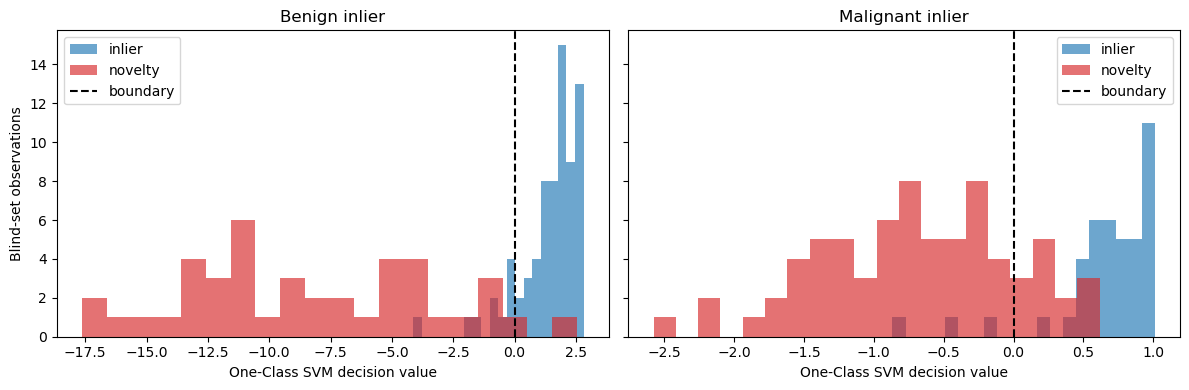

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, case in zip(axes, cases):
    y_blind = case["y_blind"]
    for label, role, color in [
        (1, "inlier", "tab:blue"),
        (-1, "novelty", "tab:red"),
    ]:
        ax.hist(
            case["decision"][y_blind == label], bins=20, alpha=0.65,
            label=role, color=color,
        )
    ax.axvline(0, color="black", linestyle="--", label="boundary")
    ax.set_title(case["name"])
    ax.set_xlabel("One-Class SVM decision value")
    ax.legend()
axes[0].set_ylabel("Blind-set observations")
plt.tight_layout()

## Feature-selection curves

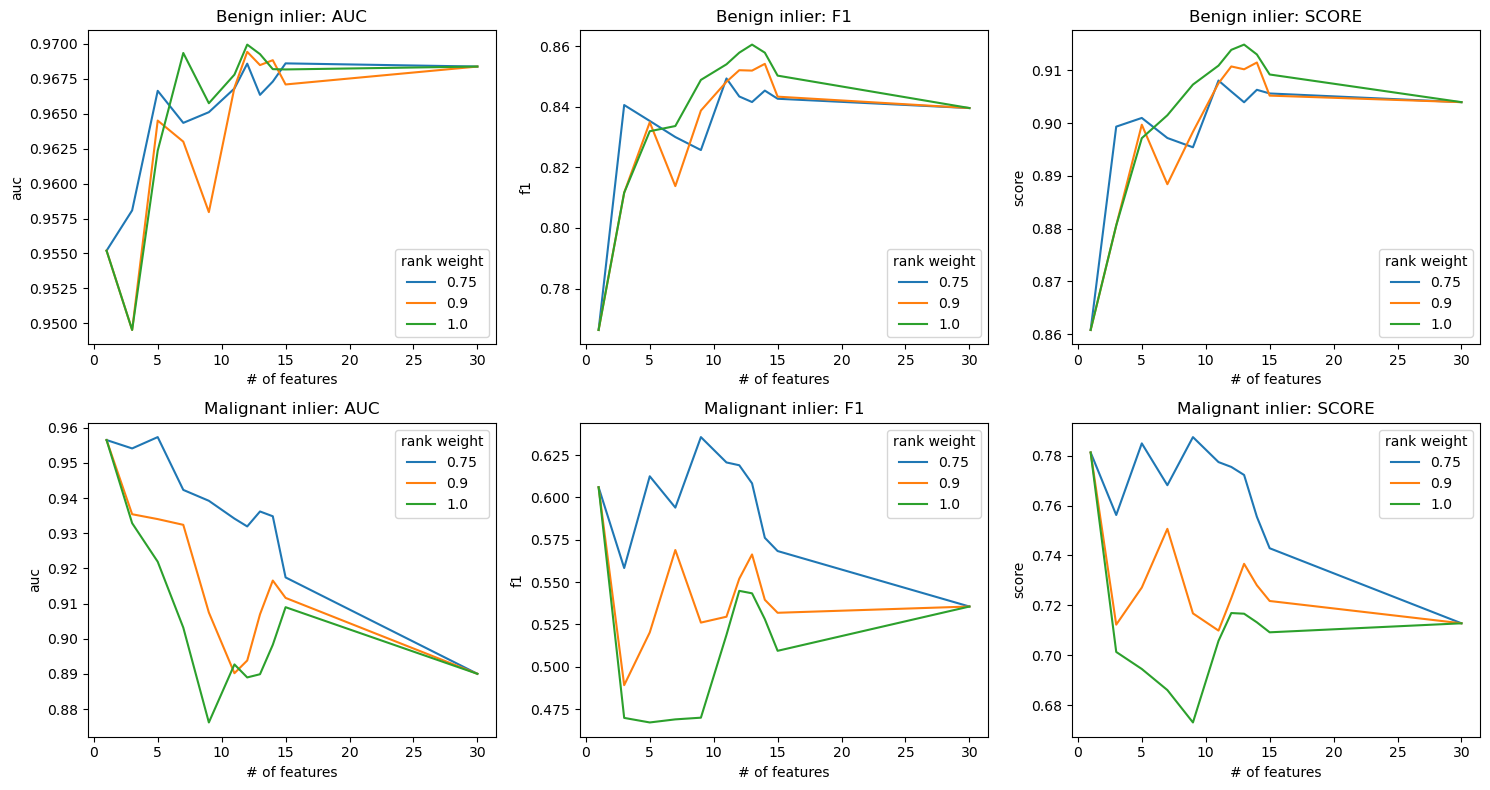

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for row, case in enumerate(cases):
    for model in case["models"]:
        for ax, metric in zip(axes[row], ["auc", "f1", "score"]):
            plt.sca(ax)
            model.plot_performance(metric=metric)
    for ax, metric in zip(axes[row], ["auc", "f1", "score"]):
        ax.set_title(f"{case['name']}: {metric.upper()}")
        ax.legend(rank_weights, title="rank weight")
plt.tight_layout()

## Selected features across member models

In [10]:
def member_feature_table(case):
    model = case["best_model"]
    return pd.DataFrame({
        f"member_{index}": pd.Series([feature_names[i] for i in features])
        for index, features in enumerate(model.features)
    })

print("Benign-inlier members")
display(member_feature_table(benign_case))
print("Malignant-inlier members")
display(member_feature_table(malignant_case))

Benign-inlier members


,member_0,member_1,member_2,member_3,member_4
0,Radius mean,Radius mean,Radius mean,Radius mean,Radius mean
1,Perimeter mean,Perimeter mean,Perimeter mean,Perimeter mean,Texture mean
2,Area mean,Area mean,Area mean,Area mean,Perimeter mean
3,Concave Points mean,Compactness mean,Concave Points mean,Concave Points mean,Area mean
4,Fractal Dimension mean,Concave Points mean,Fractal Dimension mean,Radius worst,Smoothness mean
5,Smoothness SE,Fractal Dimension mean,Radius worst,Perimeter worst,Concave Points mean
6,Compactness SE,Radius worst,Perimeter worst,Area worst,Radius worst
7,Concave Points SE,Perimeter worst,Area worst,Smoothness worst,Texture worst
8,Symmetry SE,Area worst,Compactness worst,Compactness worst,Perimeter worst
9,Radius worst,Compactness worst,Concavity worst,Concavity worst,Area worst


Malignant-inlier members


,member_0,member_1,member_2,member_3,member_4
0,Perimeter mean,Compactness mean,Perimeter mean,Perimeter mean,Compactness mean
1,Concavity mean,Concavity mean,Concavity mean,Concavity mean,Concavity mean
2,Texture worst,Concave Points mean,Concave Points mean,Concave Points mean,Concave Points mean
3,Compactness worst,Perimeter worst,Perimeter worst,Perimeter worst,Symmetry mean
4,Concave Points worst,Concave Points worst,Concave Points worst,Concave Points worst,Concave Points worst


## Perturbation contribution and objective importance

For each selected model, the table reports signed local decision contribution, squared contribution energy for descriptive purposes, and the separate quadratic-objective importance. Feature selection itself uses the compression-based rank, not squared contribution energy.

In [11]:
def perturbation_summary(case, member_index=0):
    model = case["best_model"]
    X = case["X_blind"]
    contributions = model.decision_perturbation_(member_index, X)
    importance = model.feature_importance_(member_index)
    groups = model._active_perturbation_sets(member_index)
    return pd.DataFrame({
        "feature": [feature_names[group[0]] for group in groups],
        "mean_signed_contribution": contributions.mean(axis=0),
        "mean_squared_contribution": np.mean(contributions**2, axis=0),
        "objective_importance": importance,
    }).sort_values("mean_squared_contribution", ascending=False)

print("Benign-inlier perturbations")
display(perturbation_summary(benign_case))
print("Malignant-inlier perturbations")
display(perturbation_summary(malignant_case))

Benign-inlier perturbations


,feature,mean_signed_contribution,mean_squared_contribution,objective_importance
6,Compactness SE,-0.386467,0.194311,2.200633
3,Concave Points mean,-0.329735,0.128637,1.247611
4,Fractal Dimension mean,-0.254124,0.087378,1.610315
7,Concave Points SE,-0.227963,0.071299,1.263107
8,Symmetry SE,-0.218224,0.069849,1.551296
11,Concave Points worst,-0.230602,0.068683,0.975670
5,Smoothness SE,-0.206736,0.064911,1.276227
2,Area mean,-0.202148,0.046933,0.826843
9,Radius worst,-0.194165,0.040720,0.713440
10,Perimeter worst,-0.194257,0.040572,0.695145


Malignant-inlier perturbations


,feature,mean_signed_contribution,mean_squared_contribution,objective_importance
4,Concave Points worst,-0.883968,0.851664,5.338353
2,Texture worst,-0.753480,0.663053,5.330887
1,Concavity mean,-0.774040,0.614316,5.364493
3,Compactness worst,-0.658819,0.453134,4.850639
0,Perimeter mean,-0.608139,0.402926,4.560884


## Integrated-gradient summaries for both inlier choices

In [12]:
rng = np.random.default_rng(0)
ig_results = {}
for case in cases:
    y_blind = case["y_blind"]
    indices = np.concatenate([
        rng.choice(np.flatnonzero(y_blind == label), size=12, replace=False)
        for label in (-1, 1)
    ])
    ig_results[case["name"]] = case["best_model"].explain_integrated_gradients(
        case["X_blind"][indices],
        feature_names=feature_names,
        target=y_blind[indices],
        model_index=None,
        num_steps=20,
    )

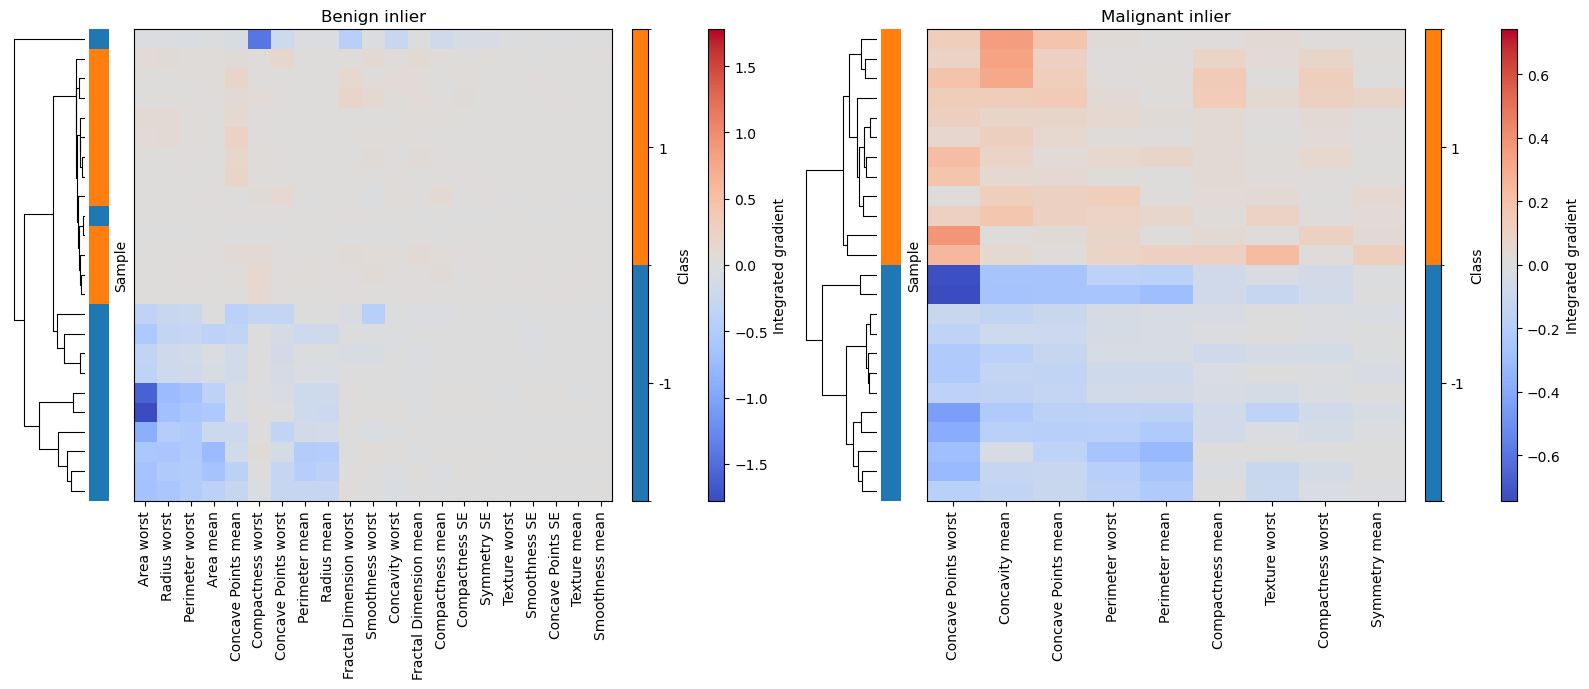

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, case in zip(axes, cases):
    ig_results[case["name"]].heatmap(
        ax=ax,
        cluster=True,
        cmap="coolwarm",
        imshow_kwargs={"rasterized": True},
        target_strip_width=0.20,
        strip_pad=0.25,
        colorbar_width=0.16,
        colorbar_pad=0.2,
        colorbar_gap=0.6,
    )
    ax.set_title(case["name"])
plt.tight_layout()

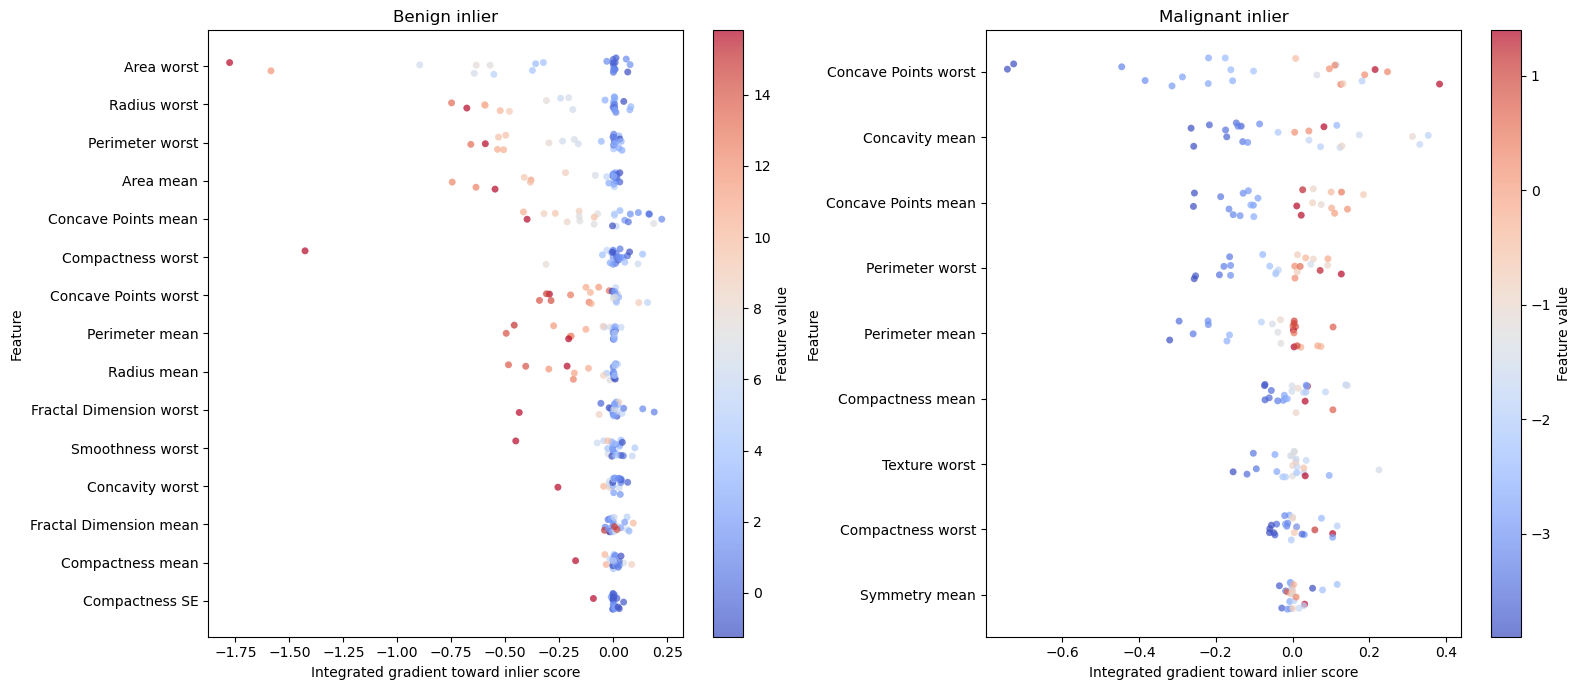

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, case in zip(axes, cases):
    ig_results[case["name"]].summary_plot(
        ax=ax,
        max_features=15,
        cmap="coolwarm",
        random_state=0,
        scatter_kwargs={"s": 25, "alpha": 0.7, "edgecolors": "none"},
    )
    ax.set_title(case["name"])
    ax.set_xlabel("Integrated gradient toward inlier score")
plt.tight_layout()